# sudoku_solver パイプライン動作確認

`sudoku_solver` パッケージ（グリッド検出 → セル分割/空白判定 → 数字認識 → ソルバー）が
一連の流れとして動作することを、`old/sudoku.jpg` を使って目視確認するためのノートブック。

各モジュールの詳細な自動テストは `tests/` にある。ここでは中間結果を画像・テキストで
可視化し、「実際に動いているか」を素早く確認することを目的とする。

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

from sudoku_solver.cells import is_blank_cell, split_into_cells
from sudoku_solver.digit_recognition import recognize_digit, recognize_grid
from sudoku_solver.grid_detection import detect_grid
from sudoku_solver.pipeline import UnsolvableGridError, solve_sudoku_from_image
from sudoku_solver.solver import solve_board

SAMPLE_IMAGE = "old/sudoku.jpg"

def show(img, title="", cmap="gray"):
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

def print_grid(grid):
    for row in grid:
        print(" ".join(str(v) if v else "." for v in row))

## 1. グリッド検出

`detect_grid` が盤面の4頂点を検出し、正面ビューに透視変換できているかを確認する。

c:\Users\PC_user\repos\sudoku-solver\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26908 (\N{CJK UNIFIED IDEOGRAPH-691C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC_user\repos\sudoku-solver\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC_user\repos\sudoku-solver\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12375 (\N{HIRAGANA LETTER SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC_user\repos\sudoku-solver\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12383 (\N{HIRAGANA LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC_user\repos\sudoku-solver\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Gl

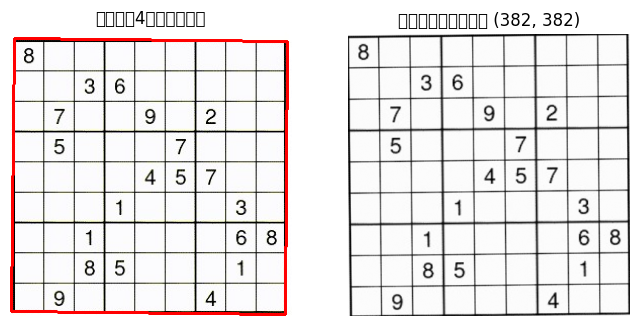

In [2]:
warped, rect = detect_grid(SAMPLE_IMAGE)

original = cv2.imread(SAMPLE_IMAGE)
overlay = original.copy()
cv2.polylines(overlay, [rect.astype(int)[[0, 1, 3, 2]]], True, (0, 0, 255), 2)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("検出した4頂点（赤枠）")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(warped, cmap="gray")
plt.title(f"正面ビューに補正後 {warped.shape}")
plt.axis("off")
plt.show()

## 2. セル分割・空白判定

9x9に分割し、各セルが空白かどうかを判定する。`.`が空白判定されたセル。

# . . . . . . . .
. . # # . . . . .
. # . . # . # . .
. # . . . # . . .
. . . . # # # . .
. . . # . . . # .
. . # . . . . # #
. . # # . . . # .
. # . . . . # . .


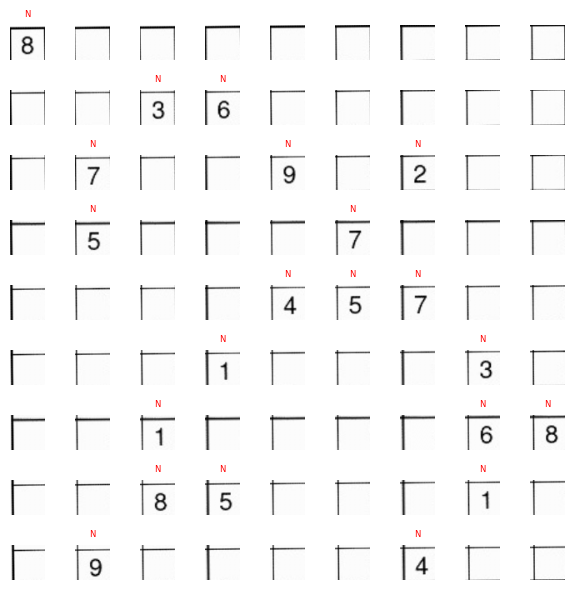

In [3]:
cell_rows = split_into_cells(warped)
blank_mask = [[is_blank_cell(cell_rows[i][j]) for j in range(9)] for i in range(9)]

for row in blank_mask:
    print(" ".join("." if b else "#" for b in row))

fig, axes = plt.subplots(9, 9, figsize=(6, 6))
for i in range(9):
    for j in range(9):
        axes[i][j].imshow(cell_rows[i][j], cmap="gray")
        axes[i][j].axis("off")
        if not blank_mask[i][j]:
            axes[i][j].set_title("N", fontsize=6, color="red")
plt.tight_layout()
plt.show()

## 3. 数字認識

`recognize_grid` で読み取った盤面を表示する。`old/sudoku.jpg`の正解は目視で確認済みのものを併記する
（`tests/test_digit_recognition.py`の`GROUND_TRUTH`と同じ）。

In [4]:
GROUND_TRUTH = [
    [8, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 3, 6, 0, 0, 0, 0, 0],
    [0, 7, 0, 0, 9, 0, 2, 0, 0],
    [0, 5, 0, 0, 0, 7, 0, 0, 0],
    [0, 0, 0, 0, 4, 5, 7, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 3, 0],
    [0, 0, 1, 0, 0, 0, 0, 6, 8],
    [0, 0, 8, 5, 0, 0, 0, 1, 0],
    [0, 9, 0, 0, 0, 0, 4, 0, 0],
]

recognized = recognize_grid(cell_rows, is_blank_cell)

print("認識結果:")
print_grid(recognized)

correct = sum(
    recognized[i][j] == GROUND_TRUTH[i][j] for i in range(9) for j in range(9)
)
print(f"\n正解: {correct}/81 ({correct / 81:.0%})")

print("\n誤りセル (行, 列, 正解, 認識結果):")
for i in range(9):
    for j in range(9):
        if recognized[i][j] != GROUND_TRUTH[i][j]:
            print(f"  ({i},{j}) expected={GROUND_TRUTH[i][j]} got={recognized[i][j]}")

認識結果:
8 . . . . . . . .
. . 3 6 . . . . .
. 7 . . . . 2 . .
. 5 . . . 7 . . .
. . . . 4 5 7 . .
. . . 1 . . . 3 .
. . 1 . . . . 6 8
. . 8 5 . . . 1 .
. . . . . . 4 . .

正解: 79/81 (98%)

誤りセル (行, 列, 正解, 認識結果):
  (2,4) expected=9 got=0
  (8,1) expected=9 got=0


## 4. ソルバー接続（エンドツーエンド）

`solve_sudoku_from_image` で画像から解答まで一気通貫で実行する。
数字認識に誤りがあり盤面が矛盾する/解けない場合は `UnsolvableGridError` になる。

In [5]:
try:
    solved = solve_sudoku_from_image(SAMPLE_IMAGE)
    print("解けました:")
    print_grid(solved)
except UnsolvableGridError as e:
    print(f"解けませんでした: {e}")
    print("\n（読み取った盤面をそのままsolve_boardに渡すと動きを確認できる）")
    print(solve_board(recognized))

解けました:
8 1 2 3 5 9 6 4 7
4 9 3 6 7 2 8 5 1
6 7 5 4 1 8 2 9 3
2 5 4 9 3 7 1 8 6
1 3 6 8 4 5 7 2 9
9 8 7 1 2 6 5 3 4
5 2 1 7 9 4 3 6 8
7 4 8 5 6 3 9 1 2
3 6 9 2 8 1 4 7 5


## 5. 合成画像でのグリッド検出頑健性デモ

実際のスマホ写真を用意しなくても、`old/sudoku.jpg`を余白付きキャンバスに貼り付けて
回転させることで、頑健性の改善（`tests/test_grid_detection_robustness.py`参照）を目視確認できる。

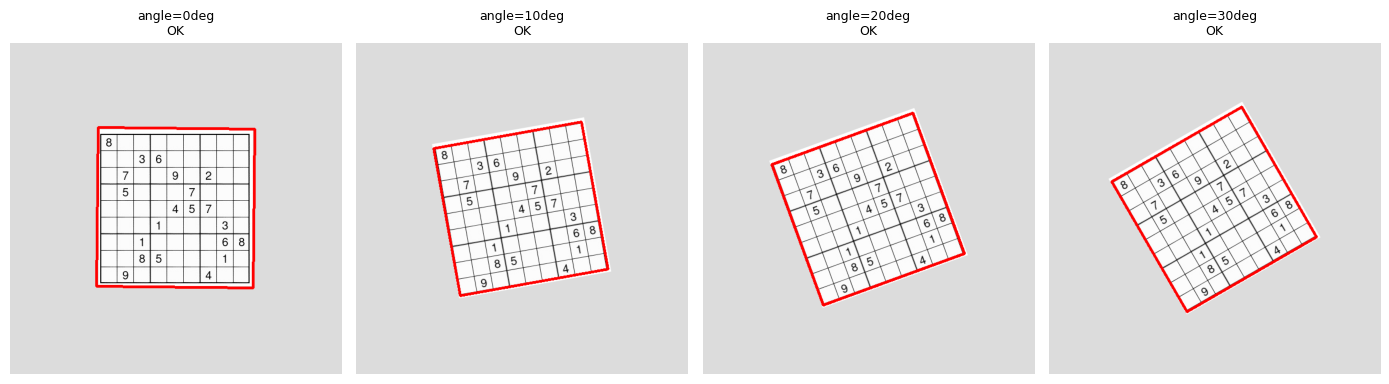

In [6]:
from sudoku_solver.grid_detection import detect_grid_from_gray
from tests.synthetic import make_photo_like

board_gray = cv2.imread(SAMPLE_IMAGE, cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, angle in zip(axes, [0, 10, 20, 30]):
    img, expected_rect = make_photo_like(board_gray, angle_deg=angle)
    display_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    try:
        _warped, rect = detect_grid_from_gray(img)
        cv2.polylines(display_img, [rect.astype(int)[[0, 1, 3, 2]]], True, (0, 0, 255), 3)
        status = "OK"
    except Exception as e:
        status = f"NG ({e})"
    ax.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"angle={angle}deg\n{status}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()